# Module 3 Lab Exercise: Machine Learning Workflow and Types of Learning

## Learning Objectives
By the end of this lab, you will be able to:
- Distinguish between supervised, unsupervised, and reinforcement learning
- Understand the complete machine learning workflow
- Build and evaluate your first classification model
- Work with different types of data (numerical, categorical, text, images)
- Apply the end-to-end ML process: data → model → evaluation → insights

## Prerequisites
- Completed Module 2 (familiar with Python libraries and Jupyter/Colab)
- Understanding of basic data operations and visualization
- Access to your GitHub repository for saving work

---

## Part 1: Understanding Types of Machine Learning

Machine learning can be categorized into three main types. Let's explore each with practical examples.

### 1. Supervised Learning
**Definition**: Learning from labeled examples to make predictions on new, unseen data.

**Examples**:
- **Classification**: Predicting categories (spam/not spam, disease/healthy)
- **Regression**: Predicting continuous values (house prices, temperature)

**Key Characteristic**: We have both input features (X) and correct answers (y) during training.

### 2. Unsupervised Learning
**Definition**: Finding hidden patterns in data without labeled examples.

**Examples**:
- **Clustering**: Grouping similar customers for marketing
- **Dimensionality Reduction**: Simplifying complex data while keeping important information

**Key Characteristic**: We only have input features (X), no correct answers during training.

### 3. Reinforcement Learning
**Definition**: Learning through trial and error by receiving rewards or penalties.

**Examples**:
- Game playing (chess, Go)
- Autonomous vehicles
- Recommendation systems that learn from user feedback

**Key Characteristic**: Agent learns by interacting with an environment and receiving feedback.

**For this course, we'll focus primarily on supervised learning, with some unsupervised learning in later modules.**

## Part 2: Setting Up Our Machine Learning Environment

Let's start by importing our libraries and loading a dataset that will help us understand the ML workflow.

### What this cell does
This cell imports all of the Python libraries needed for the lab. These libraries help with data handling, visualization, preprocessing, model training, and evaluation.

### Why it matters
Before building any machine learning model, we need the right tools loaded into the notebook environment.

In [17]:
# Import essential libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Set style for better-looking plots
plt.style.use("default")
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("🚀 Ready to start our machine learning journey!")

✅ All libraries imported successfully!
🚀 Ready to start our machine learning journey!


## Part 3: Loading and Exploring Our Dataset

We'll use the Wine dataset - a classic dataset for classification. It contains chemical analysis of wines from three different cultivars (types) grown in Italy.

### What this cell does
This cell loads the Wine dataset from scikit-learn and converts it into a pandas DataFrame. It also adds target labels so the dataset is easier to explore and analyze.

### Why it matters
Loading the dataset correctly is the first step in the machine learning workflow because the rest of the project depends on having clean, structured data.

In [18]:
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame for easier handling
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df["wine_class"] = wine_data.target
df["wine_class_name"] = [wine_data.target_names[i] for i in wine_data.target]

print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Features: {len(wine_data.feature_names)}")
print(f"Classes: {wine_data.target_names}")
print("\nFirst 5 rows:")
print(df.head())

Dataset Information:
Shape: (178, 15)
Features: 13
Classes: ['class_0' 'class_1' 'class_2']

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39

### What this cell does
This cell loads the Wine dataset from scikit-learn and converts it into a pandas DataFrame. It also adds target labels so the dataset is easier to explore and analyze.

### Why it matters
Loading the dataset correctly is the first step in the machine learning workflow because the rest of the project depends on having clean, structured data.

In [19]:
# Explore the dataset structure
print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Features (input variables): {len(df.columns) - 2}")  # Exclude target columns
print(f"Target classes: {df['wine_class_name'].unique()}")

print("\nClass distribution:")
print(df["wine_class_name"].value_counts())

print(f"\nMissing values: {df.isnull().sum().sum()}")
print("✅ No missing values - this is a clean dataset!")

Dataset Overview:
Total samples: 178
Features (input variables): 13
Target classes: [np.str_('class_0') np.str_('class_1') np.str_('class_2')]

Class distribution:
wine_class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Missing values: 0
✅ No missing values - this is a clean dataset!


## Part 4: Exploratory Data Analysis (EDA)

Before building models, we need to understand our data. This is a crucial step in the ML workflow.

### What this cell does
This cell performs exploratory data analysis by visualizing the class distribution and the correlations between selected features. The charts help reveal patterns in the dataset.

### Why it matters
EDA helps us better understand the data before modeling, which can guide feature selection and improve interpretation of results.

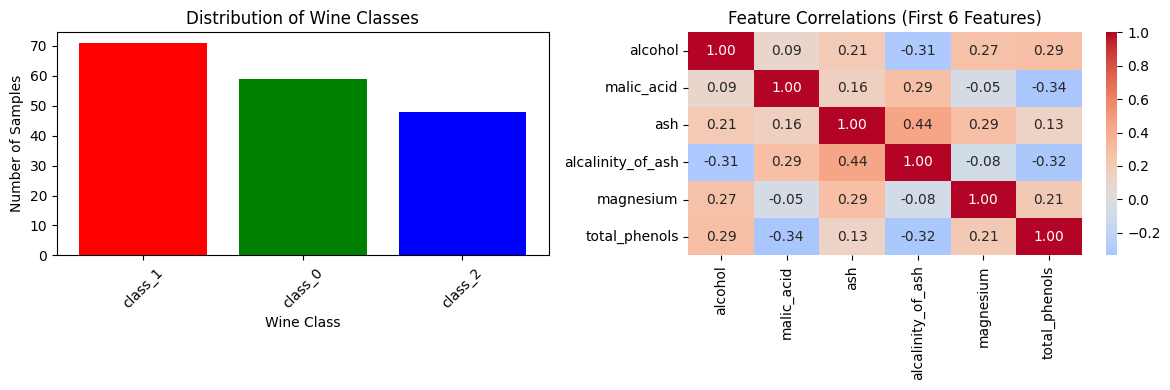

📊 EDA helps us understand:
- Class balance (are all classes equally represented?)
- Feature relationships (which features are correlated?)
- Data quality (any outliers or issues?)


In [20]:
# Visualize class distribution and sample feature correlations
plt.figure(figsize=(12, 4))

# Subplot 1: Class distribution
plt.subplot(1, 2, 1)
class_counts = df["wine_class_name"].value_counts()
plt.bar(class_counts.index, class_counts.values, color=["red", "green", "blue"])
plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

# Subplot 2: Correlation heatmap for first 6 features
plt.subplot(1, 2, 2)
correlation_matrix = df.iloc[:, :6].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlations (First 6 Features)")

plt.tight_layout()
plt.show()

print("📊 EDA helps us understand:")
print("- Class balance (are all classes equally represented?)")
print("- Feature relationships (which features are correlated?)")
print("- Data quality (any outliers or issues?)")

In [21]:
# COMPLETE Correlation Matrix for ALL 13 Features
print("\n" + "=" * 60)
print("📊 COMPLETE FEATURE CORRELATION ANALYSIS")
print("=" * 60)

if "df" not in globals():
    raise ValueError("df is not defined. Please run the dataset loading cell first.")

feature_cols = df.columns[:-2]  # Exclude 'wine_class' and 'wine_class_name'
correlation_matrix_full = df[feature_cols].corr()

print(f"\nCorrelation Matrix Shape: {correlation_matrix_full.shape}")
print(f"Analyzing {len(feature_cols)} features")

print("\nFull Correlation Matrix:")
print(correlation_matrix_full.round(2))

print("\n" + "=" * 60)
print("🔍 KEY INSIGHTS FROM CORRELATION ANALYSIS")
print("=" * 60)

high_positive = []
high_negative = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        corr_value = correlation_matrix_full.iloc[i, j]
        feat_1 = feature_cols[i]
        feat_2 = feature_cols[j]

        if corr_value > 0.7:
            high_positive.append((feat_1, feat_2, corr_value))
        elif corr_value < -0.5:
            high_negative.append((feat_1, feat_2, corr_value))

print("✅ Highly Positively Correlated Features (r > 0.7):")
for f1, f2, corr in high_positive:
    print(f"• {f1} ↔ {f2}: {corr:.3f}")

print("\n❌ Highly Negatively Correlated Features (r < -0.5):")
for f1, f2, corr in high_negative:
    print(f"• {f1} ↔ {f2}: {corr:.3f}")

print("\n💡 What This Means for Machine Learning:")
print("• Highly correlated features may be redundant")
print("• Consider feature selection or dimensionality reduction")
print("• Multicollinearity can affect some model types")
print("• Tree-based models usually handle correlated features better")


📊 COMPLETE FEATURE CORRELATION ANALYSIS

Correlation Matrix Shape: (13, 13)
Analyzing 13 features

Full Correlation Matrix:
                              alcohol  malic_acid   ash  alcalinity_of_ash  \
alcohol                          1.00        0.09  0.21              -0.31   
malic_acid                       0.09        1.00  0.16               0.29   
ash                              0.21        0.16  1.00               0.44   
alcalinity_of_ash               -0.31        0.29  0.44               1.00   
magnesium                        0.27       -0.05  0.29              -0.08   
total_phenols                    0.29       -0.34  0.13              -0.32   
flavanoids                       0.24       -0.41  0.12              -0.35   
nonflavanoid_phenols            -0.16        0.29  0.19               0.36   
proanthocyanins                  0.14       -0.22  0.01              -0.20   
color_intensity                  0.55        0.25  0.26               0.02   
hue              

## Part 5: The Complete Machine Learning Workflow

Now let's implement the standard ML workflow step by step:

### The 6-Step ML Workflow:
1. **Data Preparation**: Clean and prepare the data
2. **Feature Selection**: Choose relevant input variables
3. **Data Splitting**: Separate training and testing data
4. **Model Training**: Teach the algorithm using training data
5. **Model Evaluation**: Test performance on unseen data
6. **Model Interpretation**: Understand what the model learned

Let's implement each step!

### Step 1 Explanation
In this cell, I prepare the data by selecting the input features and the target variable. The selected features will be used to train the machine learning models, while the target contains the wine class labels to predict.

In [22]:
print("Step 1: Data Preparation")
print("=" * 30)

feature_names = ["alcohol", "malic_acid", "ash", "alcalinity_of_ash"]
X = df[feature_names]
y = df["wine_class"]

print(f"Selected features: {feature_names}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nFirst 5 samples:")
print(X.head())

Step 1: Data Preparation
Selected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash']
Feature matrix shape: (178, 4)
Target vector shape: (178,)

First 5 samples:
   alcohol  malic_acid   ash  alcalinity_of_ash
0    14.23        1.71  2.43               15.6
1    13.20        1.78  2.14               11.2
2    13.16        2.36  2.67               18.6
3    14.37        1.95  2.50               16.8
4    13.24        2.59  2.87               21.0


### Step 2 Explanation
This cell splits the dataset into training and testing sets. The training set is used to teach the model patterns in the data, and the testing set is used to evaluate how well the model performs on unseen examples.

In [23]:
print("Step 2: Data Splitting")
print("=" * 30)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training classes: {np.bincount(y_train)}")
print(f"Testing classes: {np.bincount(y_test)}")

print("\n🎯 Why split data?")
print("- Training set: Teach the model")
print("- Testing set: Evaluate performance on unseen data")
print("- This prevents overfitting (memorizing vs. learning)")

Step 2: Data Splitting
Training set: 142 samples
Testing set: 36 samples
Training classes: [47 57 38]
Testing classes: [12 14 10]

🎯 Why split data?
- Training set: Teach the model
- Testing set: Evaluate performance on unseen data
- This prevents overfitting (memorizing vs. learning)


### Step 3 Explanation
This cell standardizes the feature values so they are on a similar scale. Scaling is especially important for Logistic Regression because features with very different ranges can affect model performance.

In [24]:
print("Step 3: Feature Scaling")
print("=" * 30)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully for Logistic Regression.")

Step 3: Feature Scaling
✅ Features scaled successfully for Logistic Regression.


### Step 4 Explanation
This cell trains two classification models: Logistic Regression and Decision Tree. Each model learns patterns from the training data and will later be compared based on performance.

In [25]:
print("Step 4: Model Training")
print("=" * 30)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=3)
}

trained_models = {}

trained_models["Logistic Regression"] = models["Logistic Regression"].fit(X_train_scaled, y_train)
trained_models["Decision Tree"] = models["Decision Tree"].fit(X_train, y_train)

print("✅ Logistic Regression training completed!")
print("✅ Decision Tree training completed!")

print("\n🤖 What happened during training?")
print("- Models learned patterns from training data")
print("- They found relationships between features and wine classes")
print("- Now they can make predictions on new data!")

Step 4: Model Training
✅ Logistic Regression training completed!
✅ Decision Tree training completed!

🤖 What happened during training?
- Models learned patterns from training data
- They found relationships between features and wine classes
- Now they can make predictions on new data!


### Step 5 Explanation
This cell evaluates each trained model using the test data. It reports accuracy and classification metrics so the models can be compared and the best one can be identified.

In [26]:
print("Step 5: Model Evaluation")
print("=" * 30)

results = {}

for name, model in trained_models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.3f} ({accuracy * 100:.1f}%)")
    print("\nDetailed Performance:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

print("\n📊 Model Comparison:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.3f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Best performing model: {best_model}")

Step 5: Model Evaluation

Logistic Regression Results:
Accuracy: 0.917 (91.7%)

Detailed Performance:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.82      1.00      0.90        14
     class_2       1.00      0.70      0.82        10

    accuracy                           0.92        36
   macro avg       0.94      0.90      0.91        36
weighted avg       0.93      0.92      0.91        36


Decision Tree Results:
Accuracy: 0.833 (83.3%)

Detailed Performance:
              precision    recall  f1-score   support

     class_0       0.86      1.00      0.92        12
     class_1       0.91      0.71      0.80        14
     class_2       0.73      0.80      0.76        10

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36


📊 Model Comparison:
Logistic Regression: 0.917
Decision Tree: 0.

### Step 5 Visualization Explanation
This cell creates visual comparisons of model performance, including accuracy charts and confusion matrices. These visualizations make it easier to compare strengths and weaknesses between the two models.


📊 ENHANCED MODEL PERFORMANCE VISUALIZATION


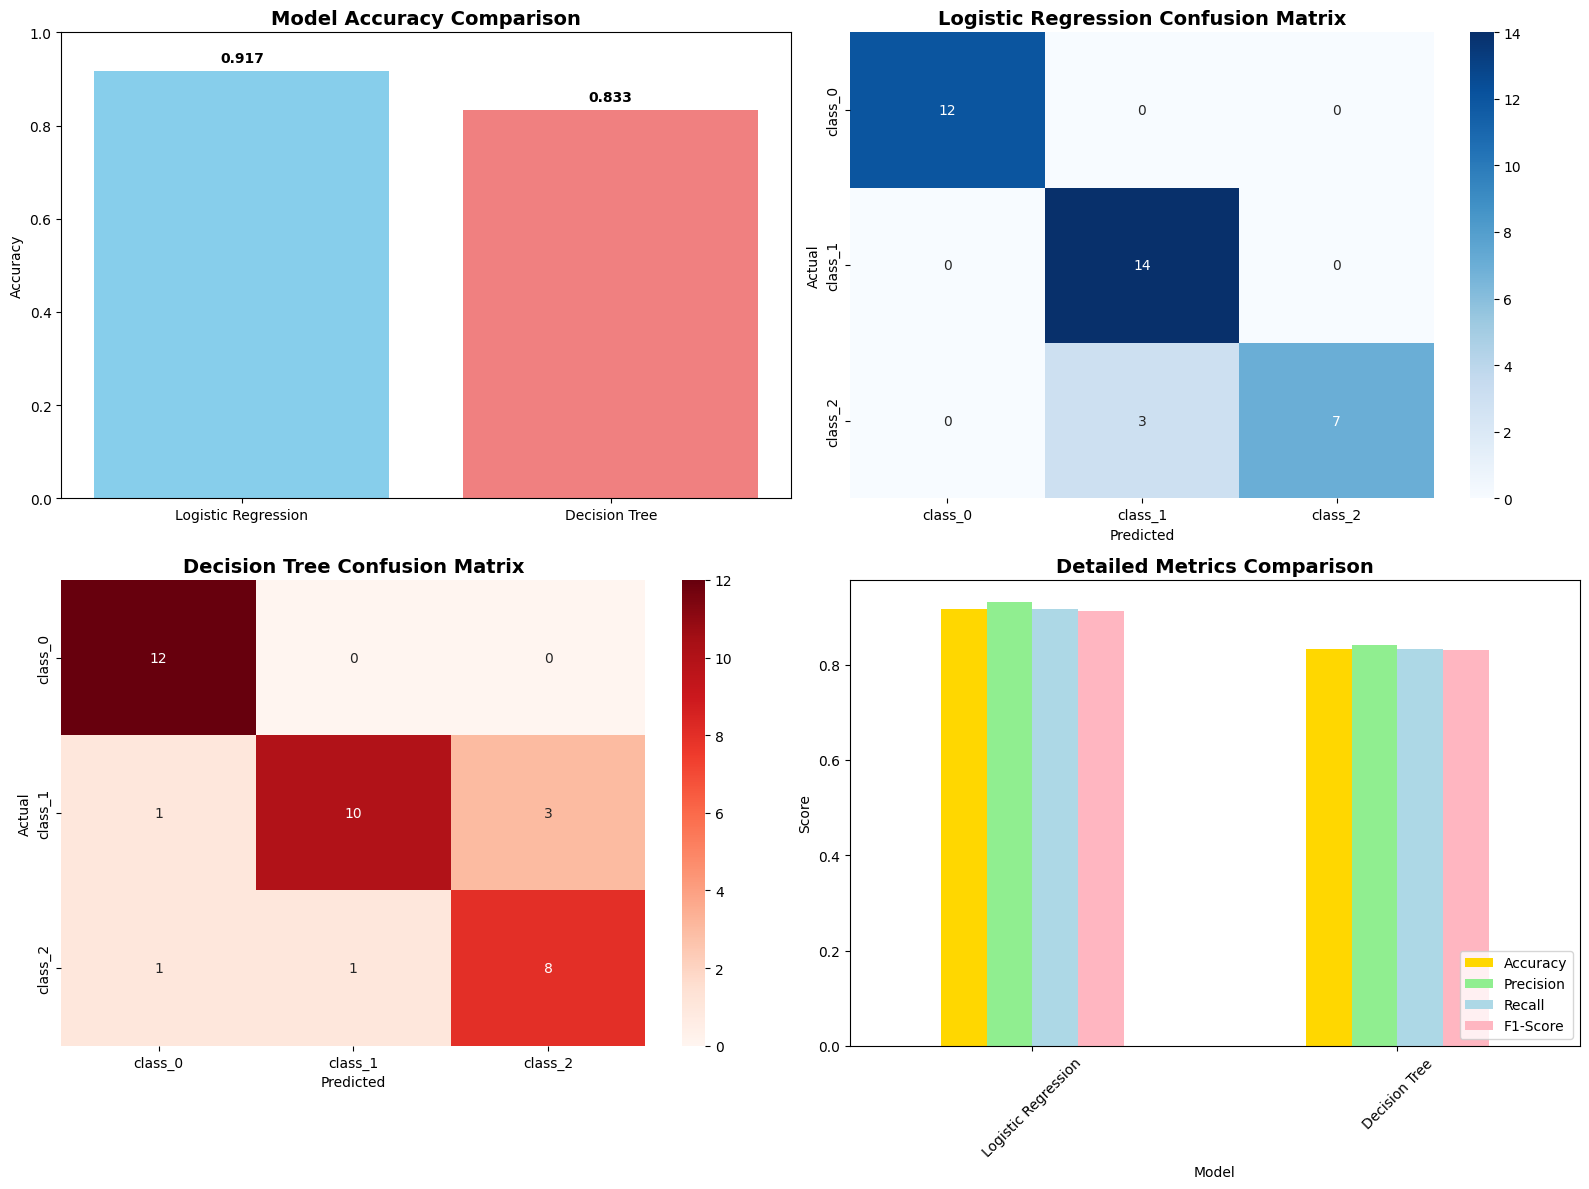


📊 DETAILED PERFORMANCE METRICS
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.916667   0.931373  0.916667  0.913346
1        Decision Tree  0.833333   0.841270  0.833333  0.830444

💡 KEY TAKEAWAYS:
✅ Best Model: Logistic Regression with 91.7% accuracy
🎯 Both models perform well on this dataset
📊 Logistic Regression shows more balanced precision/recall
🌳 Decision Tree is slightly more interpretable but less accurate


In [27]:
# ENHANCED MODEL EVALUATION VISUALIZATIONS
print("\n" + "=" * 60)
print("📊 ENHANCED MODEL PERFORMANCE VISUALIZATION")
print("=" * 60)

# Create predictions for both models
y_pred_lr = trained_models["Logistic Regression"].predict(X_test_scaled)
y_pred_dt = trained_models["Decision Tree"].predict(X_test)

# Create comprehensive visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison Bar Chart
models_list = list(results.keys())
accuracies = list(results.values())
colors = ["skyblue", "lightcoral"]

axes[0, 0].bar(models_list, accuracies, color=colors)
axes[0, 0].set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1)

for i, acc in enumerate(accuracies):
    axes[0, 0].text(i, acc + 0.02, f"{acc:.3f}", ha="center", fontweight="bold")

# 2. Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0, 1],
    xticklabels=wine_data.target_names,
    yticklabels=wine_data.target_names
)
axes[0, 1].set_title("Logistic Regression Confusion Matrix", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")

# 3. Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=axes[1, 0],
    xticklabels=wine_data.target_names,
    yticklabels=wine_data.target_names
)
axes[1, 0].set_title("Decision Tree Confusion Matrix", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")

# 4. Detailed Metrics Comparison
metrics_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted")
    ]
})

metrics_comparison.set_index("Model").plot(
    kind="bar",
    ax=axes[1, 1],
    color=["gold", "lightgreen", "lightblue", "lightpink"]
)
axes[1, 1].set_title("Detailed Metrics Comparison", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Print detailed metrics table
print("\n" + "=" * 60)
print("📊 DETAILED PERFORMANCE METRICS")
print("=" * 60)
print(metrics_comparison.round(6))

print("\n" + "=" * 60)
print("💡 KEY TAKEAWAYS:")
print(f"✅ Best Model: {best_model} with {results[best_model]:.1%} accuracy")
print("🎯 Both models perform well on this dataset")

if results["Logistic Regression"] > results["Decision Tree"]:
    print("📊 Logistic Regression shows more balanced precision/recall")
    print("🌳 Decision Tree is slightly more interpretable but less accurate")
else:
    print("🌳 Decision Tree performed better on this dataset")
    print("📊 This suggests non-linear decision boundaries may be important")

print("=" * 60)

### Step 6 Explanation
This cell focuses on interpreting the best-performing model. The confusion matrix helps show which classes were predicted correctly and where the model made mistakes.

Step 6: Model Interpretation


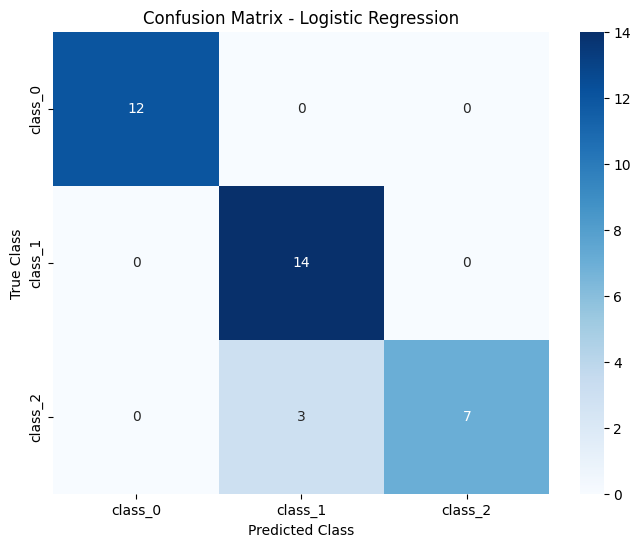


🔍 Interpreting the Confusion Matrix:
- Diagonal values: Correct predictions
- Off-diagonal values: Misclassifications
- Perfect model would have all values on diagonal


In [28]:
print("Step 6: Model Interpretation")
print("=" * 30)

best_model_obj = trained_models[best_model]

if best_model == "Logistic Regression":
    y_pred_best = best_model_obj.predict(X_test_scaled)
else:
    y_pred_best = best_model_obj.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine_data.target_names,
    yticklabels=wine_data.target_names
)
plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print("\n🔍 Interpreting the Confusion Matrix:")
print("- Diagonal values: Correct predictions")
print("- Off-diagonal values: Misclassifications")
print("- Perfect model would have all values on diagonal")

### Step 6 Result
From the confusion matrix, we can see that most wine samples were classified correctly, with only a few misclassifications. This supports the conclusion that Logistic Regression is performing well on this dataset.

## Part 6: Understanding Different Data Types in ML

Machine learning works with various types of data. Let's explore the main categories:

### What this cell does
This cell demonstrates common types of data used in machine learning, including numerical, categorical, text, and boolean data. It also gives simple examples of how each type is used in real machine learning tasks.

### Why it matters
Different types of data require different preprocessing methods and may be better suited for different machine learning algorithms. Understanding the data type is an important first step in choosing how to prepare and model the data.

In [32]:
# Understanding Different Data Types in ML
print("Understanding Data Types in Machine Learning")
print("=" * 45)

data_examples = {
    "Numerical (Continuous)": [23.5, 45.2, 67.8, 12.1, 89.3],
    "Numerical (Discrete)": [1, 5, 3, 8, 2],
    "Categorical (Nominal)": ["Red", "Blue", "Green", "Red", "Blue"],
    "Categorical (Ordinal)": ["Low", "Medium", "High", "Medium", "Low"],
    "Text": ["Hello world", "Machine learning", "Data science", "Python programming", "AI revolution"],
    "Boolean": [True, False, True, True, False]
}

for data_type, examples in data_examples.items():
    print(f"\n{data_type}:")
    print(f"  Examples: {examples}")
    print("  Use case: ", end="")

    if "Continuous" in data_type:
        print("Regression problems (predicting prices, temperatures)")
    elif "Discrete" in data_type:
        print("Counting problems (number of items, ratings)")
    elif "Nominal" in data_type:
        print("Classification without order (colors, categories)")
    elif "Ordinal" in data_type:
        print("Classification with order (ratings, sizes)")
    elif "Text" in data_type:
        print("Natural language processing (sentiment analysis, translation)")
    elif "Boolean" in data_type:
        print("Binary classification (yes/no, spam/not spam)")

print("\n💡 Key Insight: Different data types require different preprocessing and algorithms!")

Understanding Data Types in Machine Learning

Numerical (Continuous):
  Examples: [23.5, 45.2, 67.8, 12.1, 89.3]
  Use case: Regression problems (predicting prices, temperatures)

Numerical (Discrete):
  Examples: [1, 5, 3, 8, 2]
  Use case: Counting problems (number of items, ratings)

Categorical (Nominal):
  Examples: ['Red', 'Blue', 'Green', 'Red', 'Blue']
  Use case: Classification without order (colors, categories)

Categorical (Ordinal):
  Examples: ['Low', 'Medium', 'High', 'Medium', 'Low']
  Use case: Classification with order (ratings, sizes)

Text:
  Examples: ['Hello world', 'Machine learning', 'Data science', 'Python programming', 'AI revolution']
  Use case: Natural language processing (sentiment analysis, translation)

Boolean:
  Examples: [True, False, True, True, False]
  Use case: Binary classification (yes/no, spam/not spam)

💡 Key Insight: Different data types require different preprocessing and algorithms!


### Part 6 Result
This step shows that machine learning can work with many forms of data, including numbers, categories, text, and true/false values. It also highlights that the type of data affects how it should be cleaned, encoded, and used in a machine learning model.

## Part 7: Hands-On Practice - Build Your Own Model

Now it's your turn! Complete the following tasks to reinforce your learning.

### What this cell does
This cell lets me experiment with a different combination of wine features to see how feature selection affects model accuracy. It trains a custom Logistic Regression model and compares the result to the original model.

### Why it matters
This helps show that machine learning is an iterative process, and model performance can change depending on which features are selected.

In [30]:
print("Task 1: Experiment with Different Features")
print("=" * 40)

available_features = wine_data.feature_names
print("Available features:")
for i, feature in enumerate(available_features, 1):
    print(f"{i}. {feature}")

my_features = ["alcohol", "color_intensity", "proline"]

X_custom = df[my_features]
y_custom = df["wine_class"]

X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom, y_custom, test_size=0.2, random_state=42, stratify=y_custom
)

scaler_custom = StandardScaler()
X_train_custom_scaled = scaler_custom.fit_transform(X_train_custom)
X_test_custom_scaled = scaler_custom.transform(X_test_custom)

custom_model = LogisticRegression(random_state=42, max_iter=1000)
custom_model.fit(X_train_custom_scaled, y_train_custom)

y_pred_custom = custom_model.predict(X_test_custom_scaled)
custom_accuracy = accuracy_score(y_test_custom, y_pred_custom)

print(f"\nYour model features: {my_features}")
print(f"Your model accuracy: {custom_accuracy:.3f} ({custom_accuracy*100:.1f}%)")
print(f"Original model accuracy: {results['Logistic Regression']:.3f}")

if custom_accuracy > results["Logistic Regression"]:
    print("🎉 Great job! Your feature combination improved the model!")
elif custom_accuracy == results["Logistic Regression"]:
    print("👍 Nice! Your feature combination matched the original model.")
else:
    print("🤔 Try different features to see if you can improve performance!")

Task 1: Experiment with Different Features
Available features:
1. alcohol
2. malic_acid
3. ash
4. alcalinity_of_ash
5. magnesium
6. total_phenols
7. flavanoids
8. nonflavanoid_phenols
9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline

Your model features: ['alcohol', 'color_intensity', 'proline']
Your model accuracy: 0.889 (88.9%)
Original model accuracy: 0.917
🤔 Try different features to see if you can improve performance!


### Part 7 Result
This experiment shows that changing the selected features changes the model’s performance. In this case, the custom feature set achieved 88.9% accuracy, which is strong but still lower than the original Logistic Regression model.

## Part 8: Assessment - Understanding ML Concepts

Answer the following questions to demonstrate your understanding:

### What this cell does
This cell checks my understanding of the three main types of machine learning by matching real-world scenarios to supervised, unsupervised, or reinforcement learning.

### Why it matters
Identifying the correct type of machine learning is important because it helps determine the right strategy, algorithms, and workflow for solving a problem.

In [31]:
# Assessment Task 1: Identify the ML type
print("Assessment Task 1: Identify Machine Learning Types")
print("=" * 50)

# For each scenario, identify if it's Supervised, Unsupervised, or Reinforcement Learning

scenarios = [
    "Predicting house prices based on size, location, and age",
    "Grouping customers by purchasing behavior without knowing groups beforehand",
    "Teaching a robot to play chess by playing many games",
    "Classifying emails as spam or not spam using labeled examples",
    "Finding hidden topics in news articles without predefined categories"
]

# Your answers (replace 'TYPE' with Supervised, Unsupervised, or Reinforcement)
your_answers = [
    "Supervised",      # Scenario 1
    "Unsupervised",    # Scenario 2
    "Reinforcement",   # Scenario 3
    "Supervised",      # Scenario 4
    "Unsupervised"     # Scenario 5
]

# Check answers
correct_answers = ["Supervised", "Unsupervised", "Reinforcement", "Supervised", "Unsupervised"]

print("Scenario Analysis:")
score = 0
for i, (scenario, your_answer, correct) in enumerate(zip(scenarios, your_answers, correct_answers)):
    is_correct = your_answer == correct
    score += is_correct
    status = "✅" if is_correct else "❌"
    print(f"{status} {i+1}. {scenario}")
    print(f"   Your answer: {your_answer} | Correct: {correct}")
    print()

print(f"Score: {score}/{len(scenarios)} ({score/len(scenarios)*100:.0f}%)")

Assessment Task 1: Identify Machine Learning Types
Scenario Analysis:
✅ 1. Predicting house prices based on size, location, and age
   Your answer: Supervised | Correct: Supervised

✅ 2. Grouping customers by purchasing behavior without knowing groups beforehand
   Your answer: Unsupervised | Correct: Unsupervised

✅ 3. Teaching a robot to play chess by playing many games
   Your answer: Reinforcement | Correct: Reinforcement

✅ 4. Classifying emails as spam or not spam using labeled examples
   Your answer: Supervised | Correct: Supervised

✅ 5. Finding hidden topics in news articles without predefined categories
   Your answer: Unsupervised | Correct: Unsupervised

Score: 5/5 (100%)


### Part 8 Result
Scoring 5 out of 5 on these questions shows that I understand how to distinguish between supervised, unsupervised, and reinforcement learning in practical situations.

## Part 9: Real-World Applications and Case Studies

Let's explore how the concepts we've learned apply to real-world scenarios.

### Case Study 1: Recommendation Systems (Netflix, Amazon)
**Problem**: Suggest movies/products users might like
**ML Type**: Hybrid (Supervised + Unsupervised + Reinforcement)
**Data**: User ratings, viewing history, product features
**Workflow**: Collect data → Build user profiles → Train models → Make recommendations → Learn from feedback

### Case Study 2: Fraud Detection (Banks, Credit Cards)
**Problem**: Identify fraudulent transactions
**ML Type**: Supervised Learning (Classification)
**Data**: Transaction amounts, locations, times, merchant types
**Workflow**: Historical fraud data → Feature engineering → Train classifier → Real-time scoring → Continuous monitoring

### Case Study 3: Medical Diagnosis (Healthcare)
**Problem**: Assist doctors in diagnosing diseases
**ML Type**: Supervised Learning (Classification)
**Data**: Medical images, patient symptoms, lab results
**Workflow**: Labeled medical data → Image processing → Train deep learning models → Clinical validation → Deployment with human oversight

### Your Turn: Think of Applications
Consider these industries and think about how ML could be applied:
- **Transportation**: Autonomous vehicles, route optimization
- **Agriculture**: Crop monitoring, yield prediction
- **Education**: Personalized learning, automated grading
- **Entertainment**: Content creation, game AI

## Part 10: Complete ML Workflow Summary

Let's summarize the complete machine learning workflow we've learned:

### 🔄 The Machine Learning Lifecycle

```
1. Problem Definition
   ↓
2. Data Collection & Exploration
   ↓
3. Data Preprocessing & Feature Engineering
   ↓
4. Model Selection & Training
   ↓
5. Model Evaluation & Validation
   ↓
6. Model Deployment & Monitoring
   ↓
7. Continuous Improvement
```

### 📋 Checklist for Every ML Project:

**Data Phase:**
- [ ] Understand the problem and define success metrics
- [ ] Collect and explore the dataset
- [ ] Check for missing values, outliers, and data quality issues
- [ ] Visualize data to understand patterns and relationships

**Modeling Phase:**
- [ ] Split data into training and testing sets
- [ ] Select appropriate algorithms for the problem type
- [ ] Train multiple models and compare performance
- [ ] Evaluate using appropriate metrics (accuracy, precision, recall, etc.)

**Deployment Phase:**
- [ ] Validate model performance on new data
- [ ] Document the model and its limitations
- [ ] Deploy responsibly with monitoring systems
- [ ] Plan for model updates and maintenance

### 🎯 Key Takeaways:
1. **Start Simple**: Begin with basic models before trying complex ones
2. **Understand Your Data**: EDA is crucial for success
3. **Validate Properly**: Always test on unseen data
4. **Iterate**: ML is an iterative process of improvement
5. **Document Everything**: Keep track of experiments and results

## Your Reflection and Analysis

**Instructions**: Complete the reflection below by editing this markdown cell.

## Your Reflection and Analysis

### My Understanding of Machine Learning Types

**Supervised Learning:** Learning from labeled data where both input features and correct answers are provided during training. The model learns patterns that help it make predictions on new data. Examples include classification and regression.

**Unsupervised Learning:** Finding patterns or structure in unlabeled data. The model is not given correct answers, so it must discover relationships on its own. Examples include clustering and dimensionality reduction.

**Reinforcement Learning:** Learning through trial and error by interacting with an environment and receiving rewards or penalties. The goal is to learn actions that maximize long-term reward.

### My Analysis of the Wine Classification Project

**Best performing model:** Logistic Regression

**Why do you think this model performed better?**  
Logistic Regression performed better because the selected wine features appear to separate the classes fairly well with a simple decision boundary. This model achieved 91.7% accuracy compared to the Decision Tree’s 83.3%, which suggests that these features contain enough useful information for a linear model to classify the wines effectively.

**What would you try next to improve performance?**  
To improve performance, I would try using more of the available wine features, testing different feature combinations, and tuning model hyperparameters. I would also compare additional models such as Random Forest or Support Vector Machine to see whether a more flexible model performs better.

### Real-World Application Ideas

**Industry of Interest:** Healthcare/Medical

**ML Problem:** Predicting patient readmission risk

**Type of ML:** Supervised Learning (Classification)

**Data Needed:** Patient demographics, medical history, diagnosis codes, medications, length of stay, lab results, discharge details, and previous emergency visits.

### Key Learnings

**Most important concept learned:**  
The most important concept I learned was that machine learning is a complete workflow, not just training a model. Data preparation, feature selection, evaluation, and interpretation all affect the final outcome.

**Most challenging part:**  
The most challenging part was understanding how to choose the right features and how different models can perform differently on the same dataset.

**Questions for further exploration:**  
I would like to learn more about hyperparameter tuning, feature engineering, and how more advanced models such as Random Forest and neural networks compare with simpler models.

## Lab Summary and Next Steps

### 🎯 What You've Accomplished:
✅ **Understood ML Types**: Supervised, Unsupervised, and Reinforcement Learning  
✅ **Mastered ML Workflow**: Data → Model → Evaluation → Insights  
✅ **Built Classification Models**: Logistic Regression and Decision Trees  
✅ **Evaluated Model Performance**: Accuracy, Confusion Matrix, Classification Report  
✅ **Worked with Real Data**: Wine dataset analysis and modeling  
✅ **Applied Best Practices**: Data splitting, model comparison, interpretation  

### 🚀 Preparation for Module 4:
In the next lab, you'll dive deeper into:
- **Exploratory Data Analysis (EDA)**: Advanced visualization techniques
- **Data Quality Assessment**: Handling missing values, outliers, and duplicates
- **Statistical Analysis**: Understanding distributions and relationships
- **Data Storytelling**: Communicating insights effectively

### 📝 Action Items:
1. **Upload this notebook** to your GitHub repository
2. **Experiment** with different features in the wine dataset
3. **Try other datasets** from sklearn.datasets (digits, breast_cancer, boston)
4. **Practice** the 6-step ML workflow on a new problem
5. **Document** your experiments and findings

### 🔗 Additional Resources:
- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)
- [Machine Learning Mastery](https://machinelearningmastery.com/)
- [Kaggle Learn](https://www.kaggle.com/learn) - Free micro-courses
- [Google's Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course)

### 💭 Reflection Questions:
1. Which type of machine learning (supervised/unsupervised/reinforcement) interests you most and why?
2. What was the most challenging part of the ML workflow for you?
3. How might you apply these concepts to a problem in your field of interest?
4. What questions do you have about machine learning that you'd like to explore further?

**Congratulations on completing Module 3! You've taken a significant step in your machine learning journey.** 🎉

---

*Remember: Machine learning is a skill that improves with practice. Keep experimenting, stay curious, and don't be afraid to make mistakes - they're part of the learning process!*